In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount, compute_max_mean_returns_epcount_w_idxs
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import MazeEditor, Observation, ObservedMazeEditor, ObservedMazeEditorWithGoal
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer
from jaxued.environments.maze import Level, ObservedLevel
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

from jax.profiler import start_trace, stop_trace

In [4]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_obs_gen"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_1808977/3239372705.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [5]:
# region PPO helper functions    
@struct.dataclass
class TrainState:
    update_count: int
    pro_train_state: BaseTrainState
    critic_train_state: BaseTrainState
    adv_train_state: BaseTrainState

def compute_gae(
    gamma: float,
    lambd: float,
    last_value: chex.Array,
    values: chex.Array,
    rewards: chex.Array,
    dones: chex.Array,
    traj_idxs: chex.Array
) -> Tuple[chex.Array, chex.Array]:
    """This takes in arrays of shape (NUM_STEPS, NUM_ENVS) and returns the advantages and targets.

    Args:
        gamma (float): 
        lambd (float): 
        last_value (chex.Array):  Shape (NUM_ENVS)
        values (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        rewards (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        dones (chex.Array): Shape (NUM_STEPS, NUM_ENVS)

    Returns:
        Tuple[chex.Array, chex.Array]: advantages, targets; each of shape (NUM_STEPS, NUM_ENVS)
    """
    def compute_gae_at_timestep(carry, x):
        gae, next_value, cur_idx = carry
        traj_started = cur_idx <= traj_idxs
    
        value, reward, done = x
        delta = reward + gamma * next_value * (1 - done) * traj_started - value
        gae = delta + gamma * lambd * (1 - done) * gae
        return (gae, jnp.where(traj_started, value, next_value), cur_idx - 1), gae

    _, advantages = jax.lax.scan(
        compute_gae_at_timestep,
        (jnp.zeros_like(last_value), last_value, values.shape[0]),
        (values, rewards, dones),
        reverse=True,
        unroll=16,
    )
    return advantages, advantages + values


class ActorCritic(nn.Module):
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(16, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.append(img_embed, dir_embed, axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.tanh(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))


class AdversaryActorCritic(nn.Module):
    # The adversary's network architecture
    action_dim: Sequence[int]
    max_timesteps: int = 50
    
    @nn.compact
    def __call__(self, inputs: Tuple[Observation, chex.Array], hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(128, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(jnp.concatenate((obs.image, jnp.expand_dims(obs.observation_map, axis=-1), obs.agent_observations), axis=-1))
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        time_value = nn.Embed(self.max_timesteps + 1, 10, name="time_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.time, None, self.max_timesteps))
        random_z_value = obs.random_z
        embedding = jnp.concatenate((img_embed, time_value, random_z_value, obs.place_goal[..., None]), axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.relu(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)

        # Mask out this
        actor_mean = jnp.where(obs.action_mask, actor_mean, -jnp.inf)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))


class Critic(nn.Module):
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(16, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.append(img_embed, dir_embed, axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))

In [6]:
env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
crit_env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=False, fully_obs=True)
adv_env = ObservedMazeEditorWithGoal(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'], agents=1)
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8)
env_renderer = MazeRenderer(env, tile_size=8)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

In [7]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def create_train_state(rng):
    def create_inner_train_state(rng, env, env_params, network_cls, prefix, network_kws={}):
        def linear_schedule(count):
            frac = (
                1.0
                - (count // (config[f"{prefix}num_minibatches"] * config[f"{prefix}epoch_ppo"]))
                / config["num_updates"]
            )
            return config[f"{prefix}lr"] * frac
        obs, _ = env.reset_to_level(rng, sample_empty_level(), env_params)
        obs = jax.tree_map(
            lambda x: jnp.repeat(jnp.repeat(x[None, ...], config["num_train_envs"], axis=0)[None, ...], 256, axis=0),
            obs,
        )
        init_x = (obs, jnp.zeros((256, config["num_train_envs"])))
        network = network_cls(env.action_space(env_params).n, **network_kws)
        network_params = network.init(rng, init_x, network_cls.initialize_carry((config["num_train_envs"],)))
        tx = optax.chain(
            optax.clip_by_global_norm(config[f"{prefix}max_grad_norm"]),
            optax.adam(learning_rate=linear_schedule, eps=1e-5),
            # optax.adam(learning_rate=config[f"{prefix}lr"], eps=1e-5),
        )
        return BaseTrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
    rng_pro, rng_crit, rng_adv = jax.random.split(rng, 3)
    return TrainState(
        update_count = 0,
        pro_train_state = create_inner_train_state(rng_pro, env, env_params, ActorCritic, "student_"),
        critic_train_state = create_inner_train_state(rng_crit, crit_env, adv_env_params, Critic, "student_"),
        adv_train_state = create_inner_train_state(rng_adv, adv_env, adv_env_params, AdversaryActorCritic, "adv_", network_kws={"max_timesteps": config["adv_num_steps"]})
    )

In [8]:
rng, _rng = jax.random.split(rng)
train_state = create_train_state(_rng)

# Adv Environment

In [104]:
init_levels = jax.tree_map(lambda x: jnp.array([x]).repeat(config["num_train_envs"], axis=0), sample_empty_level())
num_envs = config["num_train_envs"]
max_episode_length = config["student_num_steps"]
max_adv_episode_length = config["adv_num_steps"]

pro_train_state = train_state.pro_train_state
adv_train_state = train_state.adv_train_state


rng, _rng = jax.random.split(rng)
adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), init_levels, adv_env_params)
init_student_obs_mask = jnp.ones((num_envs, adv_env.action_space(adv_env_params).n), dtype=jnp.bool_)

# Create Padded Trajectory accounting for max size of adversary trajectory
adv_init_traj = (
    adv_init_obs, 
    jnp.zeros(num_envs, dtype=jnp.int32),
    jnp.zeros(num_envs, dtype=jnp.int32),
    jnp.zeros(num_envs, dtype=jnp.bool_),
    jnp.zeros(num_envs, dtype=jnp.float32),
    jnp.zeros(num_envs, dtype=jnp.float32),
    {}
)

def pad_traj(input_array: chex.Array):
    return jnp.stack([input_array] + [jnp.zeros_like(input_array)] * (max_adv_episode_length - 1))

adv_traj_idxs = jnp.zeros(num_envs, dtype=jnp.int32)
adv_init_traj = jax.tree_map(pad_traj, adv_init_traj)

# Student Step in Env
def sample_student_step(carry, _):
    rng, train_state, hstate, obs, env_state, last_done = carry
    rng, rng_action, rng_step = jax.random.split(rng, 3)

    x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
    hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
    action = pi.sample(seed=rng_action)
    log_prob = pi.log_prob(action)
    value, action, log_prob = (
        value.squeeze(0),
        action.squeeze(0),
        log_prob.squeeze(0),
    )

    next_obs, env_state, reward, done, info = jax.vmap(
        env.step, in_axes=(0, 0, 0, None)
    )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

    carry = (rng, train_state, hstate, next_obs, env_state, done)
    return carry, (obs, action, reward, done, log_prob, value, info)

# Adversary Step in Env
def sample_adv_step(carry):
    rng, train_state, hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs = carry
    rng, rng_split = jax.random.split(rng)

    keep_gen = ~jnp.all(~obs.action_mask)
    traj_not_full = adv_traj_idxs < max_adv_episode_length
    keep_gen = jnp.logical_and(keep_gen, traj_not_full)

    step_carry = hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_traj_idxs

    def take_keepgen_env_step(step_carry, keep_gen, rng):
        _, obs, _, _, _, _, adv_traj_idxs = step_carry

        def env_step():
            hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_traj_idxs = step_carry
            rng_action, rng_step = jax.random.split(rng)

            hstate = jax.tree_map(lambda x: x[None, ...], hstate)
            x = jax.tree_map(lambda x: x[None, None, ...], (obs, last_done))
            next_hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
            action = pi.sample(seed=rng_action)
            log_prob = pi.log_prob(action)
            value, action, log_prob = (
                value.squeeze(),
                action.squeeze(),
                log_prob.squeeze(),
            )

            next_hstate = jax.tree_map(lambda x : x.squeeze(0), next_hstate)

            next_obs, next_env_state, reward, done, info = adv_env.step(rng_step, env_state, action, env_params)
            action_mask = jnp.logical_and(next_obs.action_mask, student_obs_mask)
            next_obs = next_obs.replace(action_mask=action_mask, agent_observations=student_observations, place_goal=jnp.array(False, dtype=jnp.bool_))
        
            traj_step = (obs, action, reward, done, log_prob, value, info)
            
            next_step_carry = next_hstate, next_obs, next_env_state, done, student_obs_mask, student_observations, adv_traj_idxs + 1

            return next_step_carry, traj_step
        
        def empty_step():
            return step_carry, (obs, 0, 0, False, 0., 0., {})
        
        return jax.lax.cond(keep_gen,
            env_step,
            empty_step
        )
    
    (next_hstate, next_obs, next_env_state, done, _, _, adv_traj_idxs), traj_step = jax.vmap(
        take_keepgen_env_step,
        in_axes=(0, 0, 0)
    )(step_carry, keep_gen, jax.random.split(rng_split, num_envs))

    # Add next trajectory step to the full padded traj if action was available
    def update_traj(full_traj, traj_step):
        def update_at_idx(full_traj, traj_step, idx, keep_gen):
            return jax.lax.cond(keep_gen,
                lambda : jax.lax.dynamic_update_slice_in_dim(full_traj, traj_step[None, ...], idx, 0),
                lambda : full_traj
            )
        
        return jax.vmap(
            update_at_idx, in_axes=(1, 0, 0, 0)
        )(full_traj, traj_step, adv_traj_idxs, keep_gen).swapaxes(1, 0)

    adv_full_traj = jax.tree_map(update_traj, adv_full_traj, traj_step)


    carry = (
        rng, 
        train_state, 
        next_hstate, 
        next_obs, 
        next_env_state, 
        done, 
        student_obs_mask, 
        student_observations,
        adv_full_traj, 
        adv_traj_idxs
    )
    return carry

(
    rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs
) = jax.lax.while_loop(
    lambda carry : (carry[-1] < 2).all(),
    sample_adv_step,
    (
        rng,
        adv_train_state,
        AdversaryActorCritic.initialize_carry((num_envs,)),
        adv_init_obs,
        adv_init_env_state,
        jnp.zeros(num_envs, dtype=bool),
        init_student_obs_mask,
        adv_init_obs.agent_observations,
        adv_init_traj,
        adv_traj_idxs
    ),
)

# Initialise Student
rng, _rng = jax.random.split(rng)
init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), adv_last_env_state.level, env_params)

pro_carry = (
    pro_train_state, 
    ActorCritic.initialize_carry((num_envs,)), 
    init_obs, 
    init_env_state, 
    jnp.zeros(num_envs, dtype=bool)
)

adv_carry = (
    adv_train_state, 
    adv_hstate, 
    adv_last_obs, 
    adv_last_env_state, 
    adv_last_done, 
    student_obs_mask, 
    adv_full_traj, 
    adv_traj_idxs
)

# get adversary action 
def sample_step(carry, _):
    rng, pro_carry, adv_carry = carry

    pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done = pro_carry
    adv_train_state, adv_hstate, _, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs = adv_carry
    adv_last_obs = jax.vmap(adv_env.get_obs, in_axes=(0, 0))(jax.random.split(_rng, num_envs), adv_last_env_state)

    student_observations = pro_obs.agent_observation[..., None]
    student_obs_mask = jnp.concatenate([jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1]).reshape(num_envs, -1)]*3, axis=1)
    action_mask = jnp.logical_and(adv_last_obs.action_mask, student_obs_mask)

    # Prevent Goal Placing on all but the first action of the set
    student_obs_mask = jnp.logical_and(student_obs_mask, jnp.concatenate([jnp.ones((num_envs, adv_env.action_space(adv_env_params).n * 2 // 3)), jnp.zeros((num_envs, adv_env.action_space(adv_env_params).n // 3))], axis=1))

    # Get Protagonist Location
    agent_location = jnp.concatenate([pro_env_state.env_state.agent_dir[:, None], pro_env_state.env_state.agent_pos], axis=-1)

    (
        (rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs)
    ) = jax.lax.while_loop(
        lambda carry : ~jnp.logical_or(jnp.all(~carry[3].action_mask, axis=1), ~(carry[9] < max_adv_episode_length)).all(),
        #lambda carry : ~(~carry[3].action_mask).all()
        sample_adv_step,
        (
            rng,
            adv_train_state,
            adv_hstate,
            adv_last_obs.replace(action_mask=action_mask, agent_observations=student_observations),
            adv_last_env_state,
            adv_last_done,
            student_obs_mask,
            student_observations,
            adv_full_traj,
            adv_traj_idxs
        )
    )

    # update student envs
    pro_obs, pro_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, pro_env_state)

    # students act in env
    full_pro_carry, pro_traj_step = sample_student_step(
        (rng, pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done), 
        None
    )
    rng, pro_carry = full_pro_carry[0], full_pro_carry[1:]

    # Return Carry
    adv_carry = (adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs)
    carry = (rng, pro_carry, adv_carry)

    return carry, (pro_traj_step, adv_traj_idxs, agent_location)

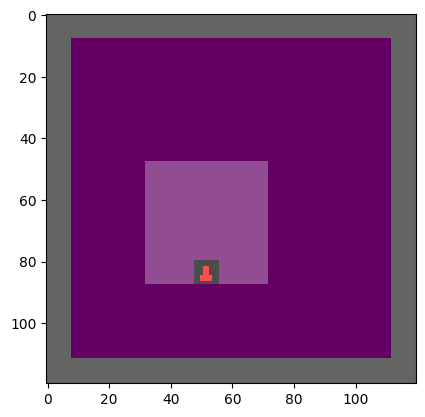

In [105]:
LEVEL_NUM = 5

level = jax.tree_map(lambda x : x[LEVEL_NUM], adv_last_env_state)
image = adv_env_renderer.render_state(level.level, adv_env_params)
plt.imshow(image)

In [108]:
(rng, pro_carry, adv_carry), (pro_traj, adv_traj_idx_array, pro_locations) = sample_step((rng, pro_carry, adv_carry), None)

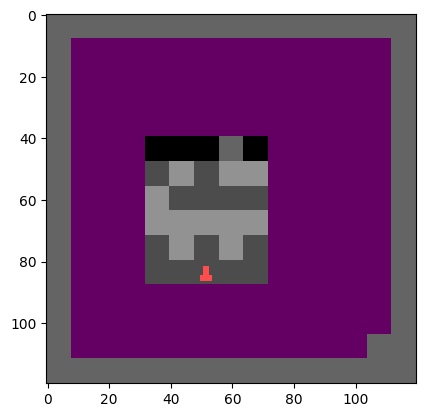

In [109]:
LEVEL_NUM = 5

level = jax.tree_map(lambda x : x[LEVEL_NUM], adv_carry[3])
image = adv_env_renderer.render_state(level.level, adv_env_params)
plt.imshow(image)

# Final Code

In [ ]:
(rng, pro_carry, adv_carry), (pro_traj, adv_traj_idx_array, pro_locations) = jax.lax.scan(
    sample_step, 
    (rng, pro_carry, adv_carry), 
    None, 
    length=max_episode_length
)

def get_last_value(carry):
    train_state, hstate, last_obs, _, last_done = carry[:5]
    x = jax.tree_map(lambda x: x[None, ...], (last_obs, last_done))
    _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)
    return last_value

last_values = get_last_value(pro_carry).squeeze(0), get_last_value(adv_carry).squeeze(0)

last_pro_env_state = pro_carry[3]
last_agent_location = jnp.concatenate([last_pro_env_state.env_state.agent_dir[:, None], last_pro_env_state.env_state.agent_pos], axis=-1)    